### Important Notes
* Make sure to install unite with the editable flag.
* If you want 64-bit precision in JAX, you need to set the relevant environment variable: "JAX_ENABLE_X64" = "1"

In [26]:
# some basic imports 
import sys, numpy, scipy, json
from astropy.table import Table
import jax, jaxlib
from unite.spectra import NIRSpecSpectra
from unite.fitting import NIRSpecFit 
from unite.utils import download_spectra

#os.environ['JAX_ENABLE_X64'] = '1' 

print(sys.version)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("jax:", jax.__version__)
print("jaxlib:", jaxlib.__version__)
print("Available backends:", jax.devices())

3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:28:54) [Clang 19.1.7 ]
numpy: 2.3.5
scipy: 1.16.3
jax: 0.5.0
jaxlib: 0.5.0
Available backends: [CpuDevice(id=0)]


Here is an example of running the code to fit two dispersers for a single spectrum. You create the table of the sources and ensure that they get loaded in correctly. To make sure different dispersers are processed together they must share the same root and srcid. 

In [27]:
from pathlib import Path
spec_dir = 'spectra'
out_dir = 'out'
table_csv = '8204.csv'

spec_names = [
    'abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_g395m-f290lp_8204_45924.spec.fits',
#    'abell2744-greene-v4_prism-clear_8204_45924.spec.fits',
]

spec_table = download_spectra(
    spec_names,
    table_csv=table_csv,
    spectra_directory=spec_dir,   # where to place the file
)

# check to see what this table looks like
spec_table['srcid','file','root','grating','grade','z','spectra_directory']
#s=Table.read(spectra_directory+'/'+spec_names[0]) 

srcid,file,root,grating,grade,z,spectra_directory
int64,str53,str19,str5,int64,float64,str7
45924,abell2744-greene-v4_g235m-f170lp_8204_45924.spec.fits,abell2744-greene-v4,G235M,3,4.4633,spectra


In [3]:
# we can test whether this table works by loading the NIRSpecSpectra class
# this will read in the spectra files and convert the data to f_lambda units automatically
# the two arguments needed are the table, and the directory where the spectra are stored
spectra = NIRSpecSpectra(rows=spec_table)
#spectra.fixed = [False, False, True] # take PRISM as reference

#defaults.LINETYPES.keys() 

Now that we know how to load in the data, we can set up the fit itself. The emission lines (and their line types) that we want to fit need to be specified in a configuration file. 
Here you can also specify absorption or cauchy components. 

In [ ]:
from dotfit import EmissionLines
from unite import defaults    
el = EmissionLines()
# explore lines like so
# el.get_table('[Fe II]',wave=[4000,4100])
# el.get_table(wave=[4000,4200])
# el.get_table('He I')
# el.get_multiplet('[FeII]-4083')

# -------------------------------------- Hg, Hd
groups = [{'name': 'Hg+FeII_gaussian'}]
groups.append({'absorption': 'Hg, Hd'}) 
groups.append({'emission': 'Hd, Hg','additional':'broad'})
groups.append({'emission': 'HeI-4027, HeI-4145, HeI-4389, HeI-4473'})
groups.append({'emission': '[NeIII]-3870,[OIII]-4364,[SII]-4070','additional':'outflow'})
# # groups.append({'emission': '[OIII]-4364, [SII]-4070'})
groups.append({'emission': '[FeII]-4081,[FeII]-4245, [FeII]-4289,[FeII]-4418'})
groups.append({'emission': '[FeII]-4289','multiplet':False})
#worse WAIC [FeII]-4404,[FeII]-4081
config = el.to_unite(groups, save=True)
# need strict limits on absorption to avoid
# degenerate solutions. Should probably tie to Hb
defaults.redshift['absorption'] = (0.0, 2*defaults.δz)
defaults.fwhm['absorption'] = (0,5)
defaults.flux['outflow'] = (0,2)

groups[0]['name'] = groups[0]['name'].replace('gaussian','exponential')
groups[2]['additional']='exponential'
config = el.to_unite(groups, save=True)

-------------------------------------- [NeIII]
groups = [{'name': 'NeIII_gaussian'}]
groups.append({'absorption': 'H7, H8, H9, H10, H11'}) 
groups.append({'emission': '[OII]-3727, H7'})
groups.append({'emission': '[NeIII]-3870', 'additional':'broad', 'TieRedshift':False})
groups.append({'emission': 'HeI-3821'}) #HeI-3873,HeI-3890
groups.append({'narrow': 'CaII-3935'}) 
config = el.to_unite(groups, save=True)

# -------------------------------------- Hb+[OIII]
# restrict fit to 4620-5060 A
# groups = [{'name': 'Hb+OIII_gaussian'}]
# groups.append({'absorption': 'Hb'}) 
# groups.append({'emission': 'Hb', 'additional':'broad'})
# # use [NeIII] to anchor the outflow
# groups.append({'emission': '[OIII]-5008,[NeIII]-3870', 'additional': 'outflow'})
# groups.append({'emission': 'HeII-4687'})  
# groups.append({'emission': 'HeI-4714,HeI-4923,HeI-5017'}) #HeI-3873,HeI-3890
# groups.append({'emission': '[FeII]-4729,[FeII]-4816'})
# # worse WAIC [FeII]-5050, [FeII]-4900, [FeII]-4967, HeI-5049
# config = el.to_unite(groups, save=True)
# defaults.fwhm['absorption'] = (0,750)
# defaults.flux['outflow'] = (0,2)

# groups[0]['name'] = groups[0]['name'].replace('gaussian','exponential')
# groups[2]['additional']='exponential'
# config = el.to_unite(groups, save=True)

# groups = [{'name': '5500_gaussian', 'region':(5030,6300)}]
# #groups.append({'emission': '[OIII]-5008','multiplet':False})
# groups.append({'emission': '[FeII]-5159,[FeII]-5160,[FeII]-5749'}) #,[FeII]-5903,[FeII]-5984'}) 
# groups.append({'emission': 'HeI-5877', 'additional':'broad'}) #HeI-3873,HeI-3890
# #groups.append({'emission': 'OI-6048'})
# groupss.append({'emission': '[NII]-5756'})
# config = el.to_unite(group, save=True)

#NaI-5892
#groups[0]['name'] = groups[0]['name'].replace('gaussian','lorentzian')
# groups[2]['additional']='lorentzian'
# config = el.to_unite(groups, save=True)
# defaults.fwhm['absorption'] = (0,750)

with open(groups[0]['name']+'.json') as f:
    config = json.load(f)
config



name Hg+FeII_gaussian
{'Name': 'Hg+FeII_gaussian', 'Unit': 'Angstrom', 'Groups': {}}
name Hg+FeII_exponential
{'Name': 'Hg+FeII_exponential', 'Unit': 'Angstrom', 'Groups': {}}


{'Name': 'Hg+FeII_exponential',
 'Unit': 'Angstrom',
 'Groups': {'absorption1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'absorption',
     'Lines': [{'Wavelength': 4341.691, 'RelStrength': None},
      {'Wavelength': 4102.899, 'RelStrength': None}]}]},
  'emission1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'emission',
     'AdditionalComponents': {'exponential': 'emission1'},
     'Lines': [{'Wavelength': 4102.899, 'RelStrength': None},
      {'Wavelength': 4341.691, 'RelStrength': None}]}]},
  'emission2': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HeI',
     'LineType': 'emission',
     'Lines': [{'Wavelength': 4027.324, 'RelStrength': None},
      {'Wavelength': 4144.928, 'RelStrength': None},
      {'Wavelength': 4389.162, 'RelStrength': None},
      {'Wavelength': 4472.729, 'RelStrength': None}]}]},
  'emission3': {'TieRedshift': True,
   'Tie

Running the fit is now easy! We use MCMC sampling as implemented in numpyro NUTS. Let's use 500 samples for warm-up, and 1000 for the actual sampling.

The fitting produces some files that store the full chains and a summary of results, and also a figure showing the fit. You can choose the location where to store these files.

In [50]:
# modified defaults
defaults.CONTINUUM = defaults.LINEPAD # less padding
defaults.emission = (0, 500)

NIRSpecFit(config, spec_table, spectra, out_dir, N=200, num_warmup=100, rescale_errors=False)

sample: 100%|██████████| 300/300 [02:21<00:00,  2.12it/s, 255 steps of size 6.22e-03. acc. prob=0.91] 


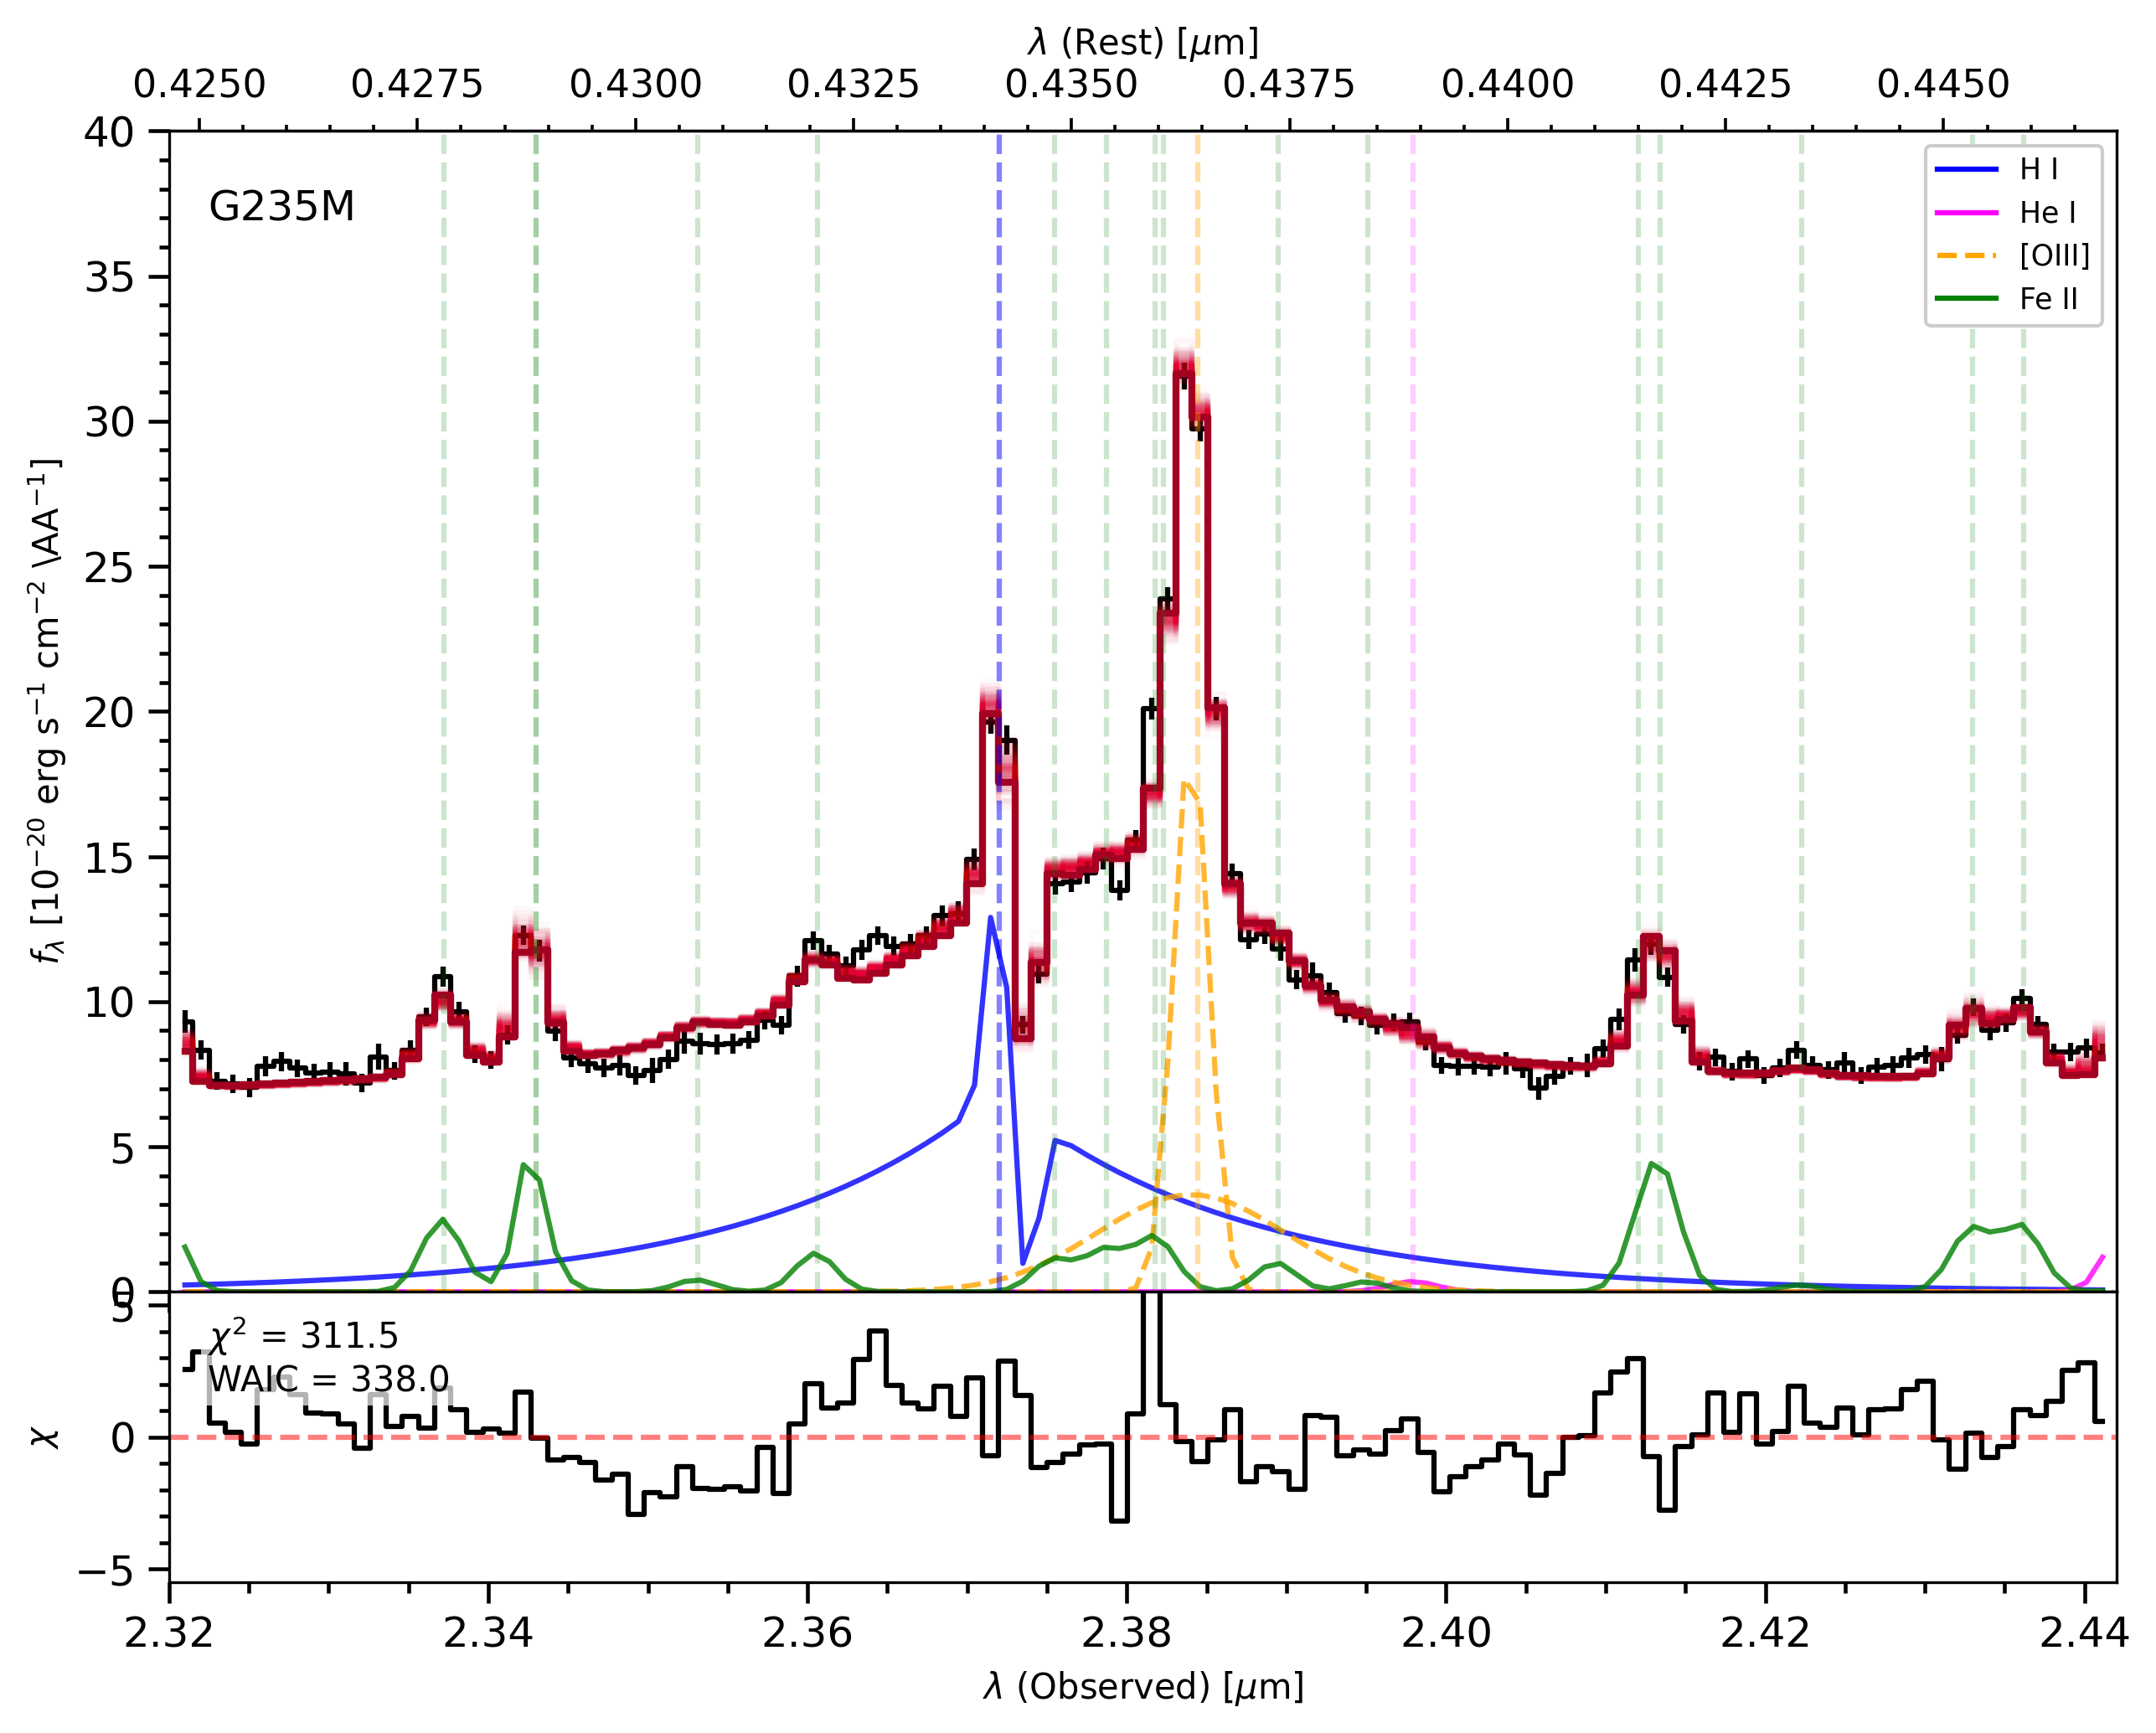

In [52]:
import importlib
import unite.plotting
importlib.reload(unite.plotting)
importlib.reload(sys.modules['unite.fitting'])
from unite.plotting import plotResults, plotRegionSingle

# recreate the output plots with other plotting options
plot_kw={"yscale": "linear","ylim":[0,40],'show_lines':True} 

# data contains the samples, components, best model index, and spectra information
fig, data = plotResults(config, rows=spec_table, output_dir=out_dir, plot_kwargs=plot_kw)

# make small zoom in plots of specific regions
ax = plotRegionSingle(config, spec_table, out_dir, 
                 spectra.spectra[0], [2.32, 2.442],
                 plot_kwargs=plot_kw)


* To change the *shape* of the priors we can edit the unite/priors.py file directly

* To change the *range* of the priors we can edit the unite/defaults.py file directly

* To change the width of the wavelength range used to fit, or the width used to find an initial estimate of the line fluxes, we can edit the unite/defaults.py file directly


In [ ]:
# tests below

In [ ]:
import jax
import jax.numpy as jnp
from numpyro import sample, deterministic
import numpyro.distributions as dist
from numpyro.distributions import Normal, HalfNormal
from numpyro.infer import MCMC, NUTS
from splinex.bspline import BSpline
import matplotlib.pyplot as plt
import numpy as np
from unite import defaults
import astropy.units as u
import importlib
importlib.reload(sys.modules['unite.spectra'])
from unite.spectra import NIRSpecSpectra

spectra = NIRSpecSpectra(rows=spec_table)

spec =  spectra.spectra[0]
_, wave_full, _, flux_full, err_full = spec()

# Define mask (True = continuum/good, False = line/bad)
line_mask = spec.maskLines(config, [0.55,5.5], 
    defaults.LINEPAD*1.5,broad_species=['HI','He','OI'],
    sigma_clip=3.0, verbose=True)

# Normalize wavelength to [0, 1] using full range
wave_min, wave_max = wave_full.min(), wave_full.max()
wave_unit = (wave_full - wave_min) / (wave_max - wave_min)
wave_unit_j = jnp.asarray(wave_unit)

# Scale flux (using median of continuum pixels only)
flux_scale = np.median(flux_full[line_mask])
flux_n = flux_full / flux_scale
err_n = err_full / flux_scale
mask_j = jnp.asarray(line_mask)

# Settings
n_knots = 13
degree = 3
n_fine = 200

# Fine uniform grid for B-spline basis
x_fine = jnp.linspace(0.0, 1.0, n_fine)

# Initialize BSpline to get the basis matrix and correct number of control points
# BSpline(n_in=...) often produces n_in + degree - 1 basis functions
bs_basis = BSpline(n_in=n_knots, n_out=n_fine, degree=degree)
Phi = jnp.asarray(bs_basis.Phi)
n_ctrl_actual = Phi.shape[1]

print(f"BSpline basis shape: {Phi.shape}. Using {n_ctrl_actual} control points.")

@jax.jit
def apply_spline(ctrls):
    # Use einsum to handle potential batch dimensions automatically
    # Phi: (n_out, n_in)
    # ctrls: (..., n_in)
    # result: (..., n_out)
    return jnp.einsum('oi, ...i -> ...o', Phi, ctrls)

def spline_model_bspline(wave_unit, flux_obs, err_obs, mask):
    # Priors on control points - use the actual number required by the basis
    ctrls = sample("ctrls", Normal(0.0, 1.5).expand([n_ctrl_actual]))
    
    # Evaluate spline on fine uniform grid
    y_fine = apply_spline(ctrls)
    
    # Interpolate to observed wavelength grid (non-uniform)
    mu = deterministic("mu", jnp.interp(wave_unit, x_fine, y_fine))
    
    sigma = sample("sigma", HalfNormal(0.5))
    
    # Likelihood with masking
    sample("flux", Normal(mu, jnp.sqrt(err_obs**2 + sigma**2)).mask(mask), obs=flux_obs)

# Run MCMC
nuts = NUTS(spline_model_bspline)
mcmc = MCMC(nuts, num_warmup=500, num_samples=1000, progress_bar=True, chain_method="sequential")
mcmc.run(jax.random.key(3), wave_unit=wave_unit_j, flux_obs=jnp.asarray(flux_n), err_obs=jnp.asarray(err_n), mask=mask_j)
post = mcmc.get_samples()

# Posterior predictive
ctrl_samples = jnp.asarray(post["ctrls"])
# Evaluate on fine grid then interp to full sorted grid
y_fine_samples = jax.vmap(apply_spline)(ctrl_samples)
mu_samples = jax.vmap(lambda y: jnp.interp(wave_unit_j, x_fine, y))(y_fine_samples) * flux_scale

mu_mean = mu_samples.mean(axis=0)
mu_std = mu_samples.std(axis=0)

# Plotting
plt.figure(figsize=(7, 4))
plt.plot(wave_full,flux_full, color='gray', alpha=0.3, label='Full Data')
plt.scatter(wave_full[line_mask], flux_full[line_mask], 1, label="PRISM data (bg)")
plt.plot(wave_full, mu_mean, color="#0077BB", lw=2.5, label="BSpline (splinex)")
plt.fill_between(wave_full, mu_mean - mu_std, mu_mean + mu_std, color="#0077BB", alpha=0.2)

# Overplot lines
opz = 1 + spec.redshift_initial
for group in config['Groups'].values():
    for species in group['Species']:
        for line in species['Lines']:
            # Wavelength in Angstrom
            lam = line['Wavelength'] * u.Unit(config['Unit'])
            # Convert to observed frame microns
            lam_obs = lam.to(u.micron).value * opz
            plt.axvline(lam_obs, color='gray', linestyle='--', alpha=0.5, lw=1, zorder=0)

plt.xlabel("wavelength")
plt.ylabel("flux")
plt.legend()
plt.ylim(0, 200)
plt.xlim(wave_full.min(),wave_full.max())
plt.yscale('symlog', linthresh=10)
# Add secondary axis for rest-frame wavelength
ax = plt.gca()
secax = ax.secondary_xaxis('top', functions=(lambda x: x / opz, lambda x: x * opz))
secax.set_xlabel('Rest Wavelength [$\\mu$m]')

plt.tight_layout()
plt.show()

sample: 100%|██████████| 1500/1500 [00:08<00:00, 168.81it/s, 63 steps of size 4.79e-02. acc. prob=0.92] 



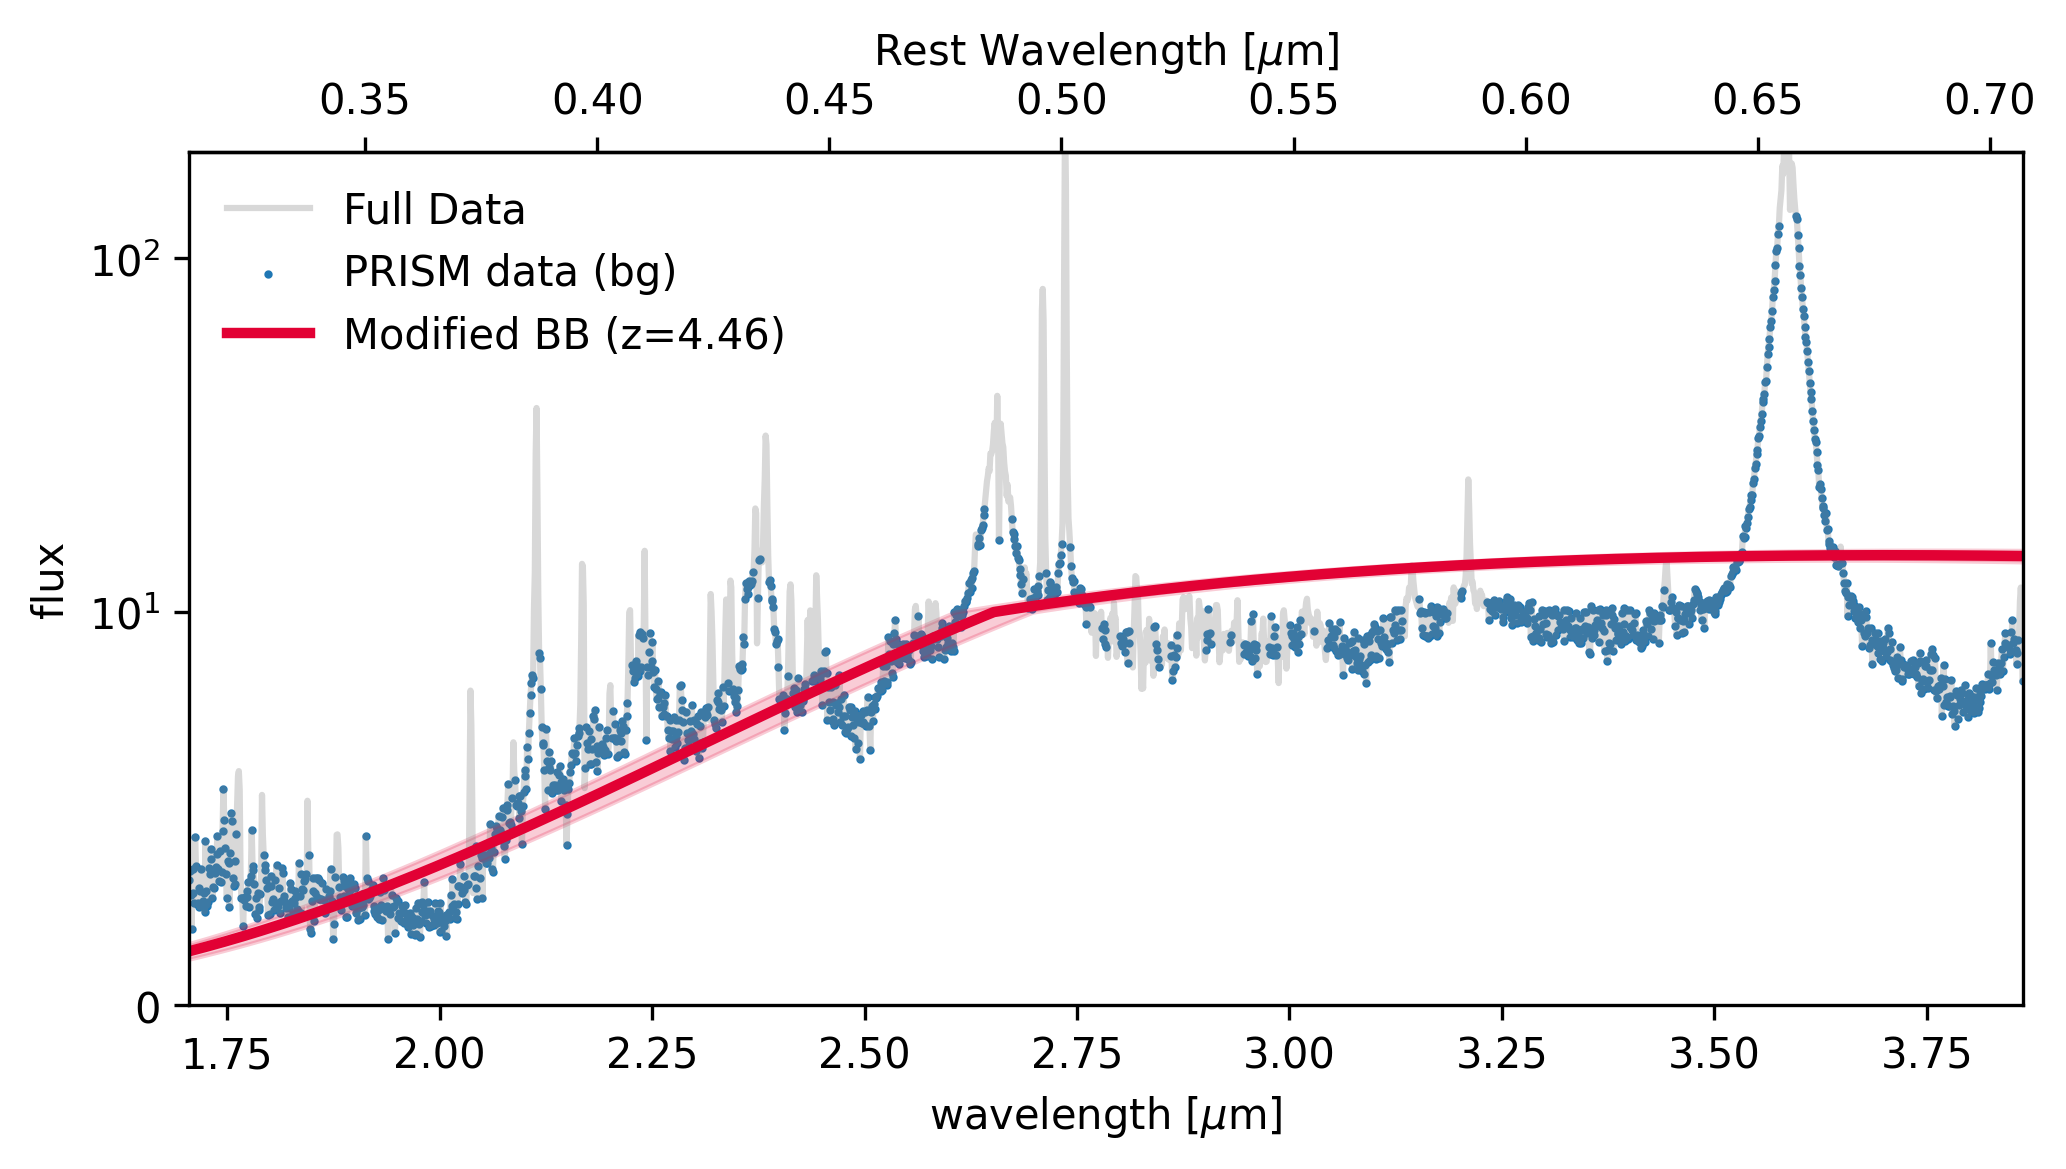

T = 3543.1 +/- 219.1 K
beta = 1.04 +/- 0.45


In [71]:
# Modified Blackbody Model (Redshifted)
def planck(wave, T):
    # wave in microns (rest frame), T in Kelvin
    # h * c / k_B ~ 1.4388e4 micron * K
    c2 = 1.4388e4 
    val = c2 / (wave * T)
    # Use a safe exponentiation to avoid overflow
    # For large val, expm1(val) ~ exp(val). 1/exp(val) = exp(-val)
    # We can compute log_bb and then exp it.
    # log(1 / (w^5 * (exp(val)-1))) = -5*log(w) - log(exp(val)-1)
    # log(exp(val)-1) = val + log(1 - exp(-val))
    # So log_bb = -5*log(w) - val - log(1 - exp(-val))
    # This is stable for large val.
    
    log_bb = -5.0 * jnp.log(wave) - val - jnp.log1p(-jnp.exp(-val))
    return jnp.exp(log_bb)

def mbb_model(wave, flux_obs, err_obs, mask, z):
    # Priors
    T = sample("T", dist.Uniform(100, 5000))
    beta = sample("beta", dist.Normal(1.5, 0.5))
    
    # Amplitude: since Planck function values can be very small/large, 
    # we let the amplitude span many orders of magnitude.
    log_amp = sample("log_amp", dist.Normal(15, 10)) 
    amp = jnp.exp(log_amp)
    
    # Calculate rest-frame wavelength
    wave_rest = wave / (1 + z)
    
    # Calculate model
    bb = planck(wave_rest, T)
    mu = deterministic("mu", amp * (wave_rest**(-beta)) * bb)
    
    # Intrinsic scatter
    sigma = sample("sigma", dist.HalfNormal(0.5))
    
    # Likelihood
    sample("flux", dist.Normal(mu, jnp.sqrt(err_obs**2 + sigma**2)).mask(mask), obs=flux_obs)

# Run MCMC
nuts_bb = NUTS(mbb_model)
mcmc_bb = MCMC(nuts_bb, num_warmup=500, num_samples=1000, progress_bar=True)
wave_j = jnp.asarray(wave_full)
z_val = spec.redshift_initial

mcmc_bb.run(jax.random.key(4), wave=wave_j, flux_obs=jnp.asarray(flux_n), err_obs=jnp.asarray(err_n), mask=mask_j, z=z_val)
post_bb = mcmc_bb.get_samples()

# Posterior predictive
mu_samples_bb = post_bb["mu"] * flux_scale
mu_mean_bb = mu_samples_bb.mean(axis=0)
mu_std_bb = mu_samples_bb.std(axis=0)

# Plotting
plt.figure(figsize=(7, 4))
plt.plot(wave_full, flux_full, color='gray', alpha=0.3, label='Full Data')
plt.scatter(wave_full[line_mask], flux_full[line_mask], 1, label="PRISM data (bg)")
plt.plot(wave_full, mu_mean_bb, color="#E20134", lw=2.5, label="Modified BB (z={:.2f})".format(z_val))
plt.fill_between(wave_full, mu_mean_bb - mu_std_bb, mu_mean_bb + mu_std_bb, color="#E20134", alpha=0.2)

plt.xlabel("wavelength [$\\mu$m]")
plt.ylabel("flux")
plt.legend()
plt.ylim(0, 200)
plt.xlim(wave_full.min(), wave_full.max())
plt.yscale('symlog', linthresh=10)

# Add secondary axis for rest-frame wavelength
ax = plt.gca()
opz = 1 + z_val
secax = ax.secondary_xaxis('top', functions=(lambda x: x / opz, lambda x: x * opz))
secax.set_xlabel('Rest Wavelength [$\\mu$m]')

plt.tight_layout()
plt.show()

# Print derived parameters
print(f"T = {post_bb['T'].mean():.1f} +/- {post_bb['T'].std():.1f} K")
print(f"beta = {post_bb['beta'].mean():.2f} +/- {post_bb['beta'].std():.2f}")

In [ ]:
# test model call 
import matplotlib.pyplot as plt
import jax.numpy as jnp
from numpyro import handlers
from unite.fitting import NIRSpecModelArgs
from unite.model import multiSpecModel

# Build model args (restricts config, computes centers, etc.)
config_r, model_args = NIRSpecModelArgs(config, rows=spec_table)
spectra, matrices, linetypes_all, line_centers, line_estimates_eq, cont_regs, cont_guesses = model_args

# Deterministic parameters: unit fluxes, constant FWHM
fwhm_guess = jnp.ones_like(line_estimates_eq) * 300.0
data = {"flux_all": jnp.ones_like(line_estimates_eq), "fwhm_all": fwhm_guess}

with handlers.seed(rng_seed=0):   # add RNG for remaining samples
    with handlers.substitute(data=data), handlers.trace() as tr:
        multiSpecModel(*model_args)

spec0 = spectra.spectra[1].name
model_flux = tr[f"{spec0}_model"]["value"]
wave = spectra.spectra[1].wave

plt.step(wave, model_flux, where="mid")
plt.xlabel("wavelength")
plt.ylabel("model flux")
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
from numpyro import sample, deterministic
from numpyro.distributions import Normal
from splinex.bspline import BSpline

def make_spline_fn(x_eval, degree=3):
    """
    Returns a JITted function that maps control points -> spline values at x_eval.
    x_eval: 1D array of eval locations in [0, 1]; BSpline builds its own knots.
    """
    n_in = x_eval.size
    bs = BSpline(n_in=n_in, n_out=x_eval.size, degree=degree)  # precompute Phi

    @jax.jit
    def apply(ctrls):
        # ctrls shape: (n_in,) or (batch, n_in)
        y, *_ = bs(ctrls)
        return y
    return apply

# Precompute once (outside the model)
x_eval = jnp.linspace(0.0, 1.0, 200)           # normalize your x to [0,1] upstream
spline_fn = make_spline_fn(x_eval, degree=3)   # captures Phi, JITs apply

def model(x_obs, y_obs, sigma_obs):
    # Priors on control points
    ctrls = sample("ctrls", Normal(0, 1).expand([x_obs.size]))

    # Spline prediction at x_obs (already normalized to [0,1])
    y_pred = deterministic("y_pred", spline_fn(ctrls))

    # Likelihood
    sample("y", Normal(y_pred, sigma_obs), obs=y_obs)

    

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from splinex.bspline import BSpline
from jax.numpy.linalg import lstsq

# Sample Data
x_data = jnp.linspace(0, 10, 50)
y_data = jnp.sin(x_data) + jnp.cos(x_data * 0.5)

# B-spline parameters
degree = 3
n_in = x_data.size

# Basis on the data grid
bs_data = BSpline(n_in=n_in, n_out=n_in, degree=degree)
S = bs_data.Phi  # (n_out x n_in)

# Solve control points that best fit the data
ctrls, res, rank, s = lstsq(S, y_data, rcond=None)

# Evaluate on a finer grid
x_fit = jnp.linspace(0, 10, 200)
bs_fit = BSpline(n_in=n_in, n_out=x_fit.size, degree=degree)
y_fit = bs_fit.Phi @ ctrls

# Plot data and spline fit
plt.figure(figsize=(7, 4))
plt.plot(x_data, y_data, "o", label="data", alpha=0.6)
plt.plot(x_fit, y_fit, "-", label="B-spline fit", lw=2)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# y_fit is the smoothed spline evaluated at x_fit

In [ ]:
import jax.random as jr
from numpyro.infer import MCMC, NUTS

# Build model args once
config_r, model_args = NIRSpecModelArgs(config, rows=spec_table)

# JIT-compiled NUTS sampler; keep iterations small for a quick demo
nuts = NUTS(multiSpecModel)
mcmc = MCMC(nuts, num_warmup=50, num_samples=100, progress_bar=False, chain_method='sequential')

with cProfile.Profile() as pr:
    mcmc.run(jr.key(0), *model_args)
    pr.print_stats(sort="tottime")

samples = mcmc.get_samples()
print({k: v.shape for k, v in samples.items()})

In [ ]:
import importlib
import unite.fitting
import unite.plotting
importlib.reload(unite.fitting)
importlib.reload(unite.plotting)
from unite.plotting import plotRegionSingle

# Re-run the plot to see the components
# The plotting function now automatically computes components and handles the config mapping
plotRegionSingle(config, spectra.spectra[0], [3.45, 3.7], model_args, samples, plot_kwargs=plot_kwargs)

In [ ]:
import importlib
import unite.fitting
importlib.reload(unite.fitting)
from unite.fitting import get_components_fit

# Re-compute components with the fixed function (using fitted parameters)
components, restricted_config = get_components_fit(config, model_args, samples, method='max_prob')

# Re-plot
plotRegionSingle(config, spectra.spectra[0], [3.45, 3.7], model_args, samples, plot_kwargs=plot_kwargs, components=components)

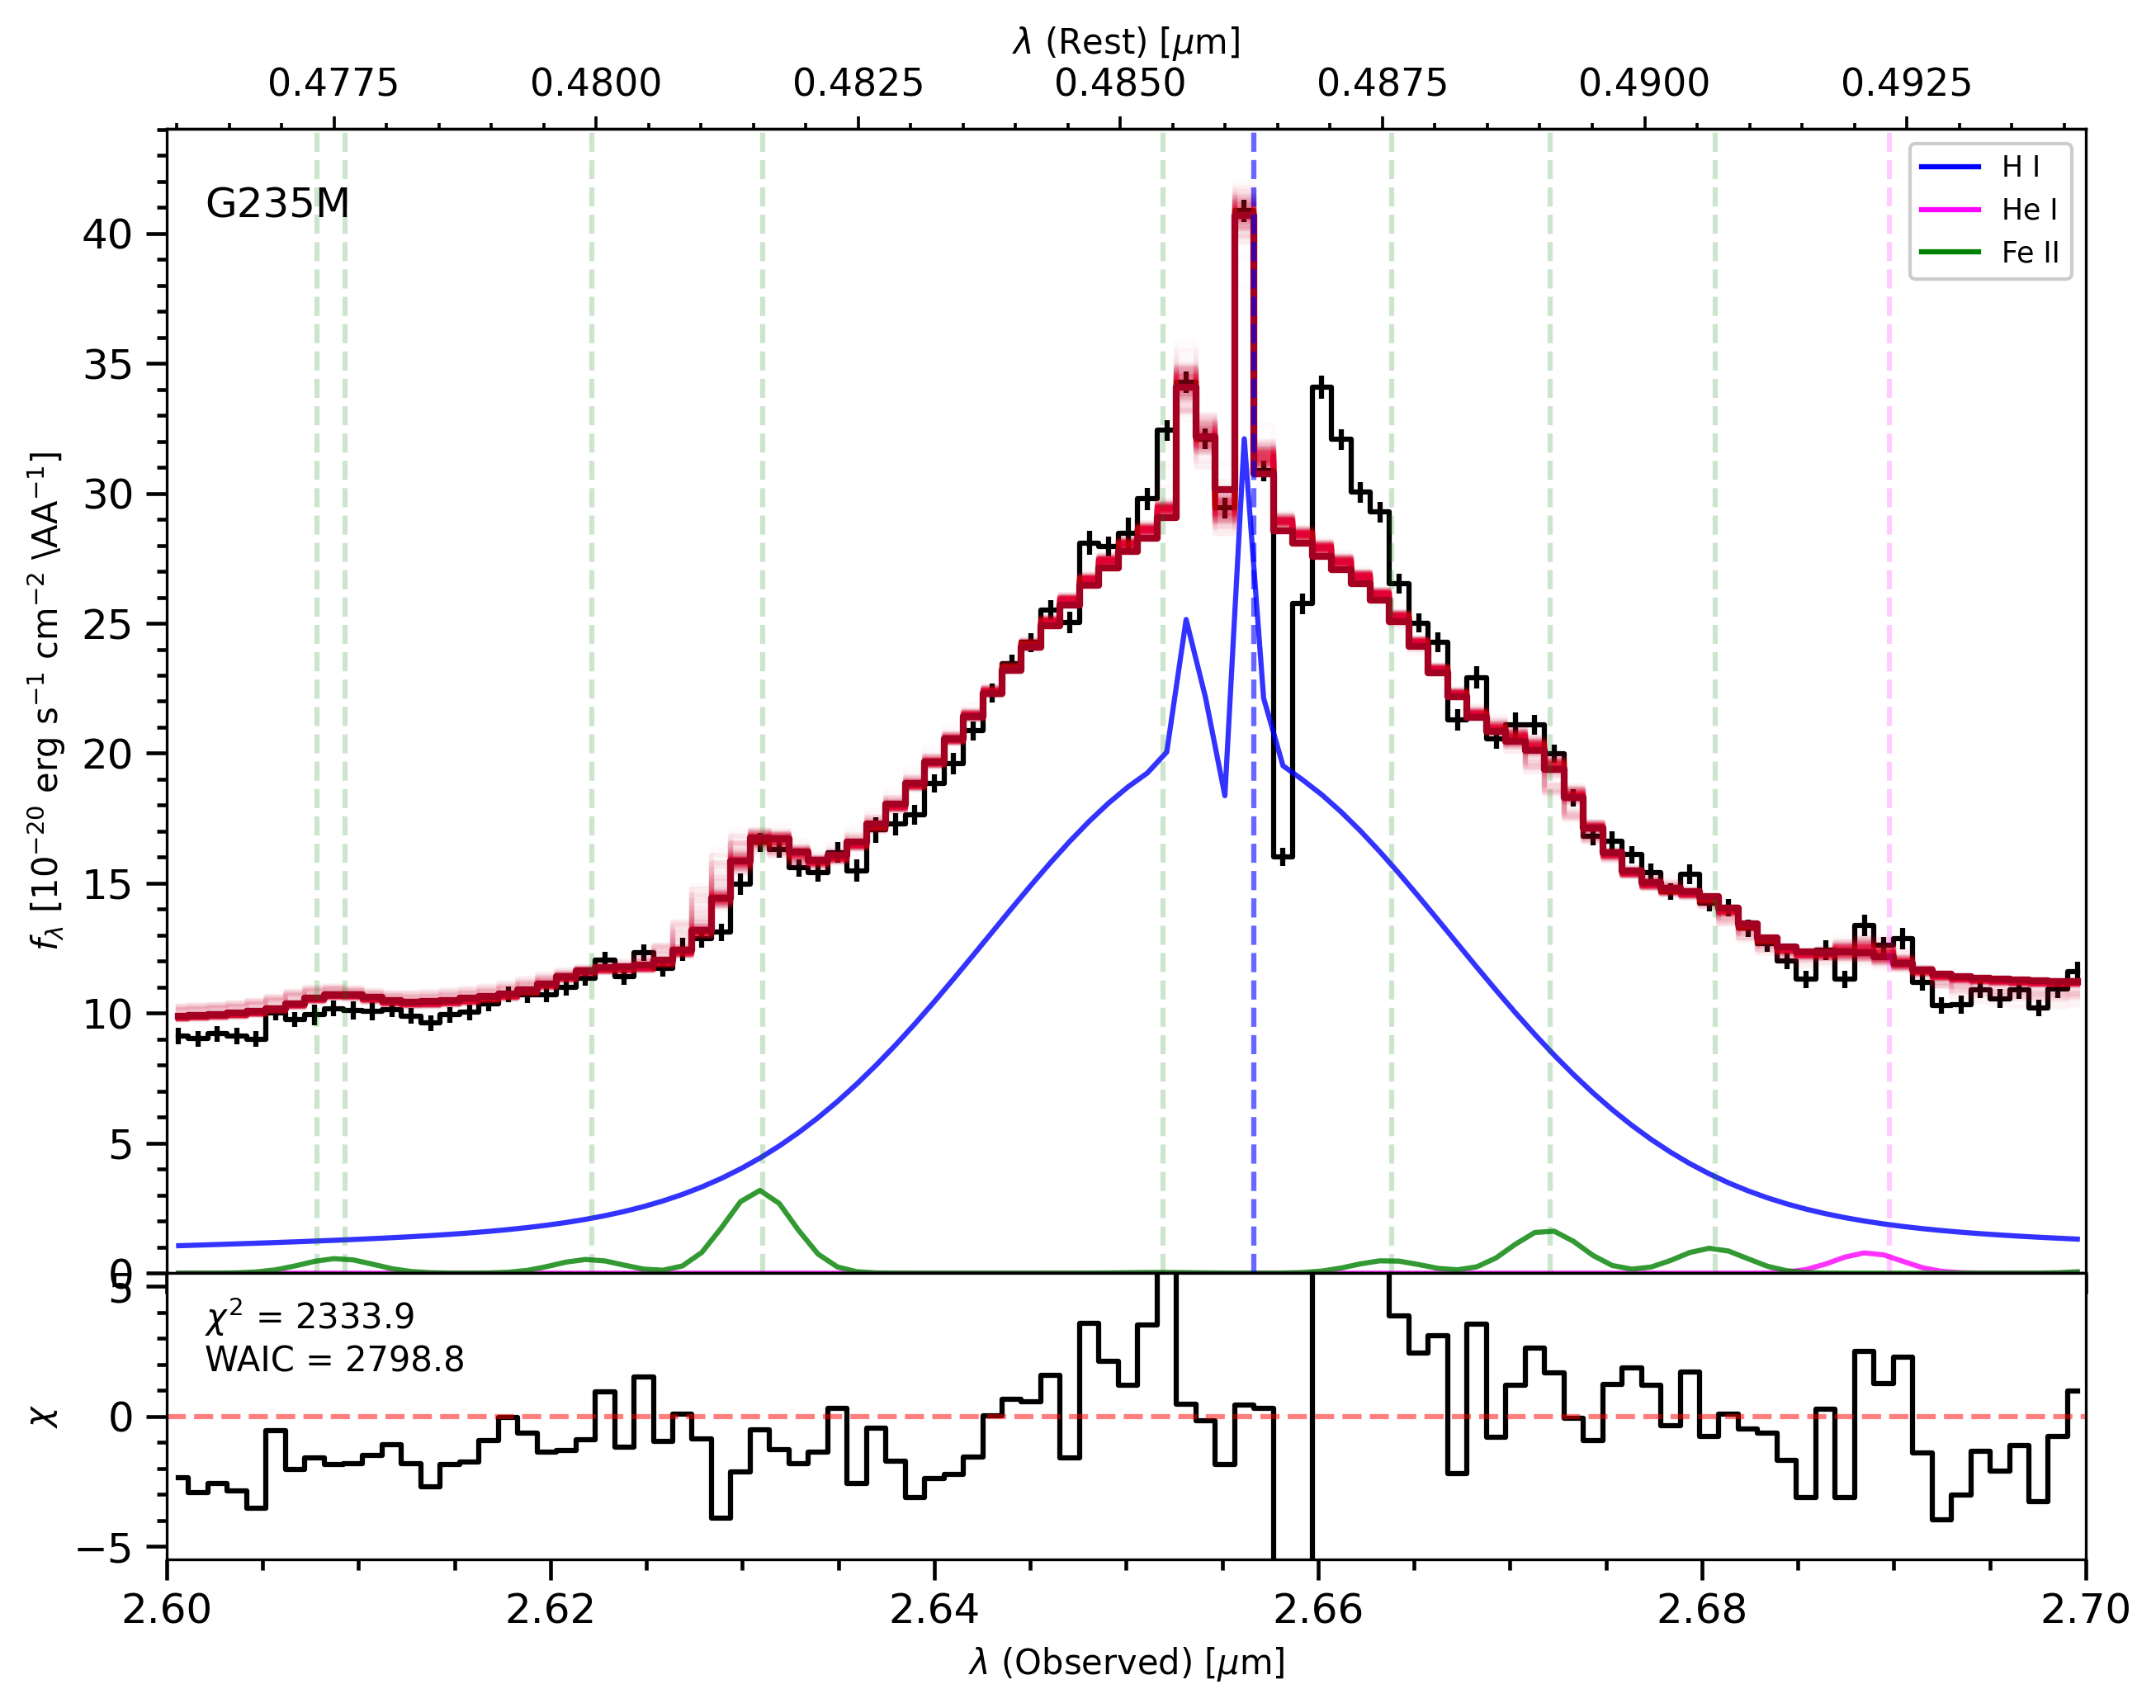

In [128]:
import importlib
import unite.fitting
importlib.reload(unite.fitting)
importlib.reload(unite.plotting)
from unite.fitting import get_components_fit
from unite.plotting import plotRegionSingle

spectra = NIRSpecSpectra(spec_table)

plotRegionSingle(config, spec_table, out_dir, spectra.spectra[0], [2.6, 2.7])

In [121]:
spectra.spectra